In [101]:
##Import Library
import numpy as np
import pandas as pd
 
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy import stats 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder,PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
#Regression
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
 
import joblib
 
RANDOM_STATE = 42

In [39]:
##Reading the dataset
DATA_FILE_1 = pd.read_csv("Crop Yeild Data.csv")
DATA_FILE_2 = pd.read_csv("Custom_Crops_yield_Historical_Dataset.csv")

In [40]:
DATA_FILE_1

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500,20.292,29.860,12.067
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000,20.292,29.860,12.067
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285,-3.143,9.582,-15.017
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.017,-3.143,9.582,-15.017


In [41]:
DATA_FILE_2

,Dist Code,Year,State Code,State Name,Dist Name,Crop,Area_ha,Yield_kg_per_ha,N_req_kg_per_ha,P_req_kg_per_ha,K_req_kg_per_ha,Total_N_kg,Total_P_kg,Total_K_kg,Temperature_C,Humidity_%,pH,Rainfall_mm,Wind_Speed_m_s,Solar_Radiation_MJ_m2_day
0,1,1966,14,Chhattisgarh,Durg,rice,548000.0,337.59,8.43975,4.05108,7.42698,4.624983e+06,2.219992e+06,4.069985e+06,25,80,6.5,1200,2.0,18
1,1,1966,14,Chhattisgarh,Durg,maize,3000.0,666.67,18.00009,8.00004,11.33339,5.400027e+04,2.400012e+04,3.400017e+04,22,70,6.0,800,2.5,20
2,1,1966,14,Chhattisgarh,Durg,chickpea,54000.0,500.00,9.00000,5.00000,9.00000,4.860000e+05,2.700000e+05,4.860000e+05,20,60,6.5,600,1.5,16
3,1,1967,14,Chhattisgarh,Durg,rice,547000.0,747.71,18.69275,8.97252,16.44962,1.022493e+07,4.907968e+06,8.997942e+06,25,80,6.5,1200,2.0,18
4,1,1967,14,Chhattisgarh,Durg,maize,3000.0,1000.00,27.00000,12.00000,17.00000,8.100000e+04,3.600000e+04,5.100000e+04,22,70,6.0,800,2.5,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50760,917,2016,15,Jharkhand,Singhbhum,maize,750.0,1869.97,50.48919,22.43964,31.78949,3.786689e+04,1.682973e+04,2.384212e+04,22,70,6.0,800,2.5,20
50761,917,2016,15,Jharkhand,Singhbhum,chickpea,150.0,1171.23,21.08214,11.71230,21.08214,3.162321e+03,1.756845e+03,3.162321e+03,20,60,6.5,600,1.5,16
50762,917,2017,15,Jharkhand,Singhbhum,rice,386910.0,1731.62,43.29050,20.77944,38.09564,1.674953e+07,8.039773e+06,1.473958e+07,25,80,6.5,1200,2.0,18
50763,917,2017,15,Jharkhand,Singhbhum,maize,27070.0,1507.72,40.70844,18.09264,25.63124,1.101977e+06,4.897678e+05,6.938377e+05,22,70,6.0,800,2.5,20


In [42]:
##Checking for the information
print(DATA_FILE_1.info())
print(DATA_FILE_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 2.0+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50765 entries, 0 to 50764
Data columns (total 20 columns):
 #   Column              

In [43]:
##Checking for the null values
print(DATA_FILE_1.isnull().sum())
print(DATA_FILE_2.isnull().sum())

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64
Dist Code                    0
Year                         0
State Code                   0
State Name                   0
Dist Name                    0
Crop                         0
Area_ha                      0
Yield_kg_per_ha              0
N_req_kg_per_ha              0
P_req_kg_per_ha              0
K_req_kg_per_ha              0
Total_N_kg                   0
Total_P_kg                   0
Total_K_kg                   0
Temperature_C                0
Humidity_%                   0
pH                           0
Rainfall_mm                  0
Wind_Speed_m_s               0
Solar_Radiation_MJ_m2_day    0
dtype: int64


In [44]:
##Standardize column values with converting all letters to lower case,Removing leading and railling spaces and repleasing spaces with underscores
##replacing the all non alphanumeric characters
DATA_FILE_1.columns=(DATA_FILE_1.columns.str.lower().str.strip().str.replace(" ","_").str.replace(r'[^a-z0-9]+', '_', regex=True))
DATA_FILE_2.columns=(DATA_FILE_2.columns.str.lower().str.strip().str.replace(" ","_").str.replace(r'[^a-z0-9]+', '_', regex=True))

print("DATA_FILE_1 Columns:")
print(DATA_FILE_1.columns)

print("\nDATA_FILE_2 Columns:")
print(DATA_FILE_2.columns)

DATA_FILE_1 Columns:
Index(['crop', 'crop_year', 'season', 'state', 'area', 'production',
       'annual_rainfall', 'fertilizer', 'pesticide', 'yield',
       'avg_temperature', 'max_temperature', 'min_temperature'],
      dtype='object')

DATA_FILE_2 Columns:
Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name', 'crop',
       'area_ha', 'yield_kg_per_ha', 'n_req_kg_per_ha', 'p_req_kg_per_ha',
       'k_req_kg_per_ha', 'total_n_kg', 'total_p_kg', 'total_k_kg',
       'temperature_c', 'humidity_', 'ph', 'rainfall_mm', 'wind_speed_m_s',
       'solar_radiation_mj_m2_day'],
      dtype='object')


In [45]:
##Same type of columns exist in multiple dataset so we are creating to single word to map it 
ALIASES = {

    # Crop Information
    "crop": ["crop"],
    "year": ["crop_year","year"],
    "season": ["season"],
    "state": ["state","state_name"],
    "district": ["district","dist_name"],

    # Location Codes
    "state_code": ["state_code"],
    "district_code": ["dist_code"],

    # Land Information
    "area": ["area","area_ha"],

    # Crop Output
    "production": ["production"],
    "yield": ["yield","yield_kg_per_ha"],

    # Weather Parameters
    "rainfall": ["annual_rainfall","rainfall_mm"],
    "temperature": ["avg_temperature","temperature_c"],
    "max_temperature": ["max_temperature"],
    "min_temperature": ["min_temperature"],
    "humidity": ["humidity"],
    "wind_speed": ["wind_speed_m_s"],
    "solar_radiation": ["solar_radiation_mj_m2_day"],

    # Soil Properties
    "ph": ["ph"],

    # Nutrient Requirement
    "nitrogen_required": ["n_req_kg_per_ha"],
    "phosphorus_required": ["p_req_kg_per_ha"],
    "potassium_required": ["k_req_kg_per_ha"],

    # Total Nutrients Applied
    "total_nitrogen": ["total_n_kg"],
    "total_phosphorus": ["total_p_kg"],
    "total_potassium": ["total_k_kg"],

    # Agricultural Inputs
    "fertilizer": ["fertilizer"],
    "pesticide": ["pesticide"]
}

In [48]:
##Merge the dataset two datasets have different schemas, you cannot directly merge them on all columns. The best approach is to merge them using the common keys
print(DATA_FILE_1.columns.tolist())
print(DATA_FILE_2.columns.tolist())
final_table = DATA_FILE_1.copy()

columns_to_add = [
    "n_req_kg_per_ha",
    "p_req_kg_per_ha",
    "k_req_kg_per_ha",
    "humidity_",
    "ph",
    "rainfall_mm",
    "wind_speed_m_s",
    "solar_radiation_mj_m2_day"
]

for col in columns_to_add:
    final_table[col] = DATA_FILE_2[col].iloc[:len(final_table)].values


['crop', 'crop_year', 'season', 'state', 'area', 'production', 'annual_rainfall', 'fertilizer', 'pesticide', 'yield', 'avg_temperature', 'max_temperature', 'min_temperature']
['dist_code', 'year', 'state_code', 'state_name', 'dist_name', 'crop', 'area_ha', 'yield_kg_per_ha', 'n_req_kg_per_ha', 'p_req_kg_per_ha', 'k_req_kg_per_ha', 'total_n_kg', 'total_p_kg', 'total_k_kg', 'temperature_c', 'humidity_', 'ph', 'rainfall_mm', 'wind_speed_m_s', 'solar_radiation_mj_m2_day']


In [49]:
final_table

,crop,crop_year,season,state,area,production,annual_rainfall,fertilizer,pesticide,yield,...,max_temperature,min_temperature,n_req_kg_per_ha,p_req_kg_per_ha,k_req_kg_per_ha,humidity_,ph,rainfall_mm,wind_speed_m_s,solar_radiation_mj_m2_day
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,...,33.435,14.779,8.43975,4.05108,7.42698,80,6.5,1200,2.0,18
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,...,33.435,14.779,18.00009,8.00004,11.33339,70,6.0,800,2.5,20
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,...,33.435,14.779,9.00000,5.00000,9.00000,60,6.5,600,1.5,16
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,...,33.435,14.779,18.69275,8.97252,16.44962,80,6.5,1200,2.0,18
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,...,33.435,14.779,27.00000,12.00000,17.00000,70,6.0,800,2.5,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500,...,29.860,12.067,7.83522,4.35290,7.83522,60,6.5,600,1.5,16
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000,...,29.860,12.067,1.79550,0.79800,1.79550,65,6.0,700,3.0,22
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285,...,9.582,-15.017,22.22225,10.66668,19.55558,80,6.5,1200,2.0,18
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.017,...,9.582,-15.017,37.80000,16.80000,23.80000,70,6.0,800,2.5,20


In [50]:
##Data Exploration
#Univariate analysis
numeric_cols = final_table.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = final_table.select_dtypes(include=["object", "category"]).columns.tolist()
print(numeric_cols)
print(categorical_cols)

['crop_year', 'area', 'production', 'annual_rainfall', 'fertilizer', 'pesticide', 'yield', 'avg_temperature', 'max_temperature', 'min_temperature', 'n_req_kg_per_ha', 'p_req_kg_per_ha', 'k_req_kg_per_ha', 'humidity_', 'ph', 'rainfall_mm', 'wind_speed_m_s', 'solar_radiation_mj_m2_day']
['crop', 'season', 'state']


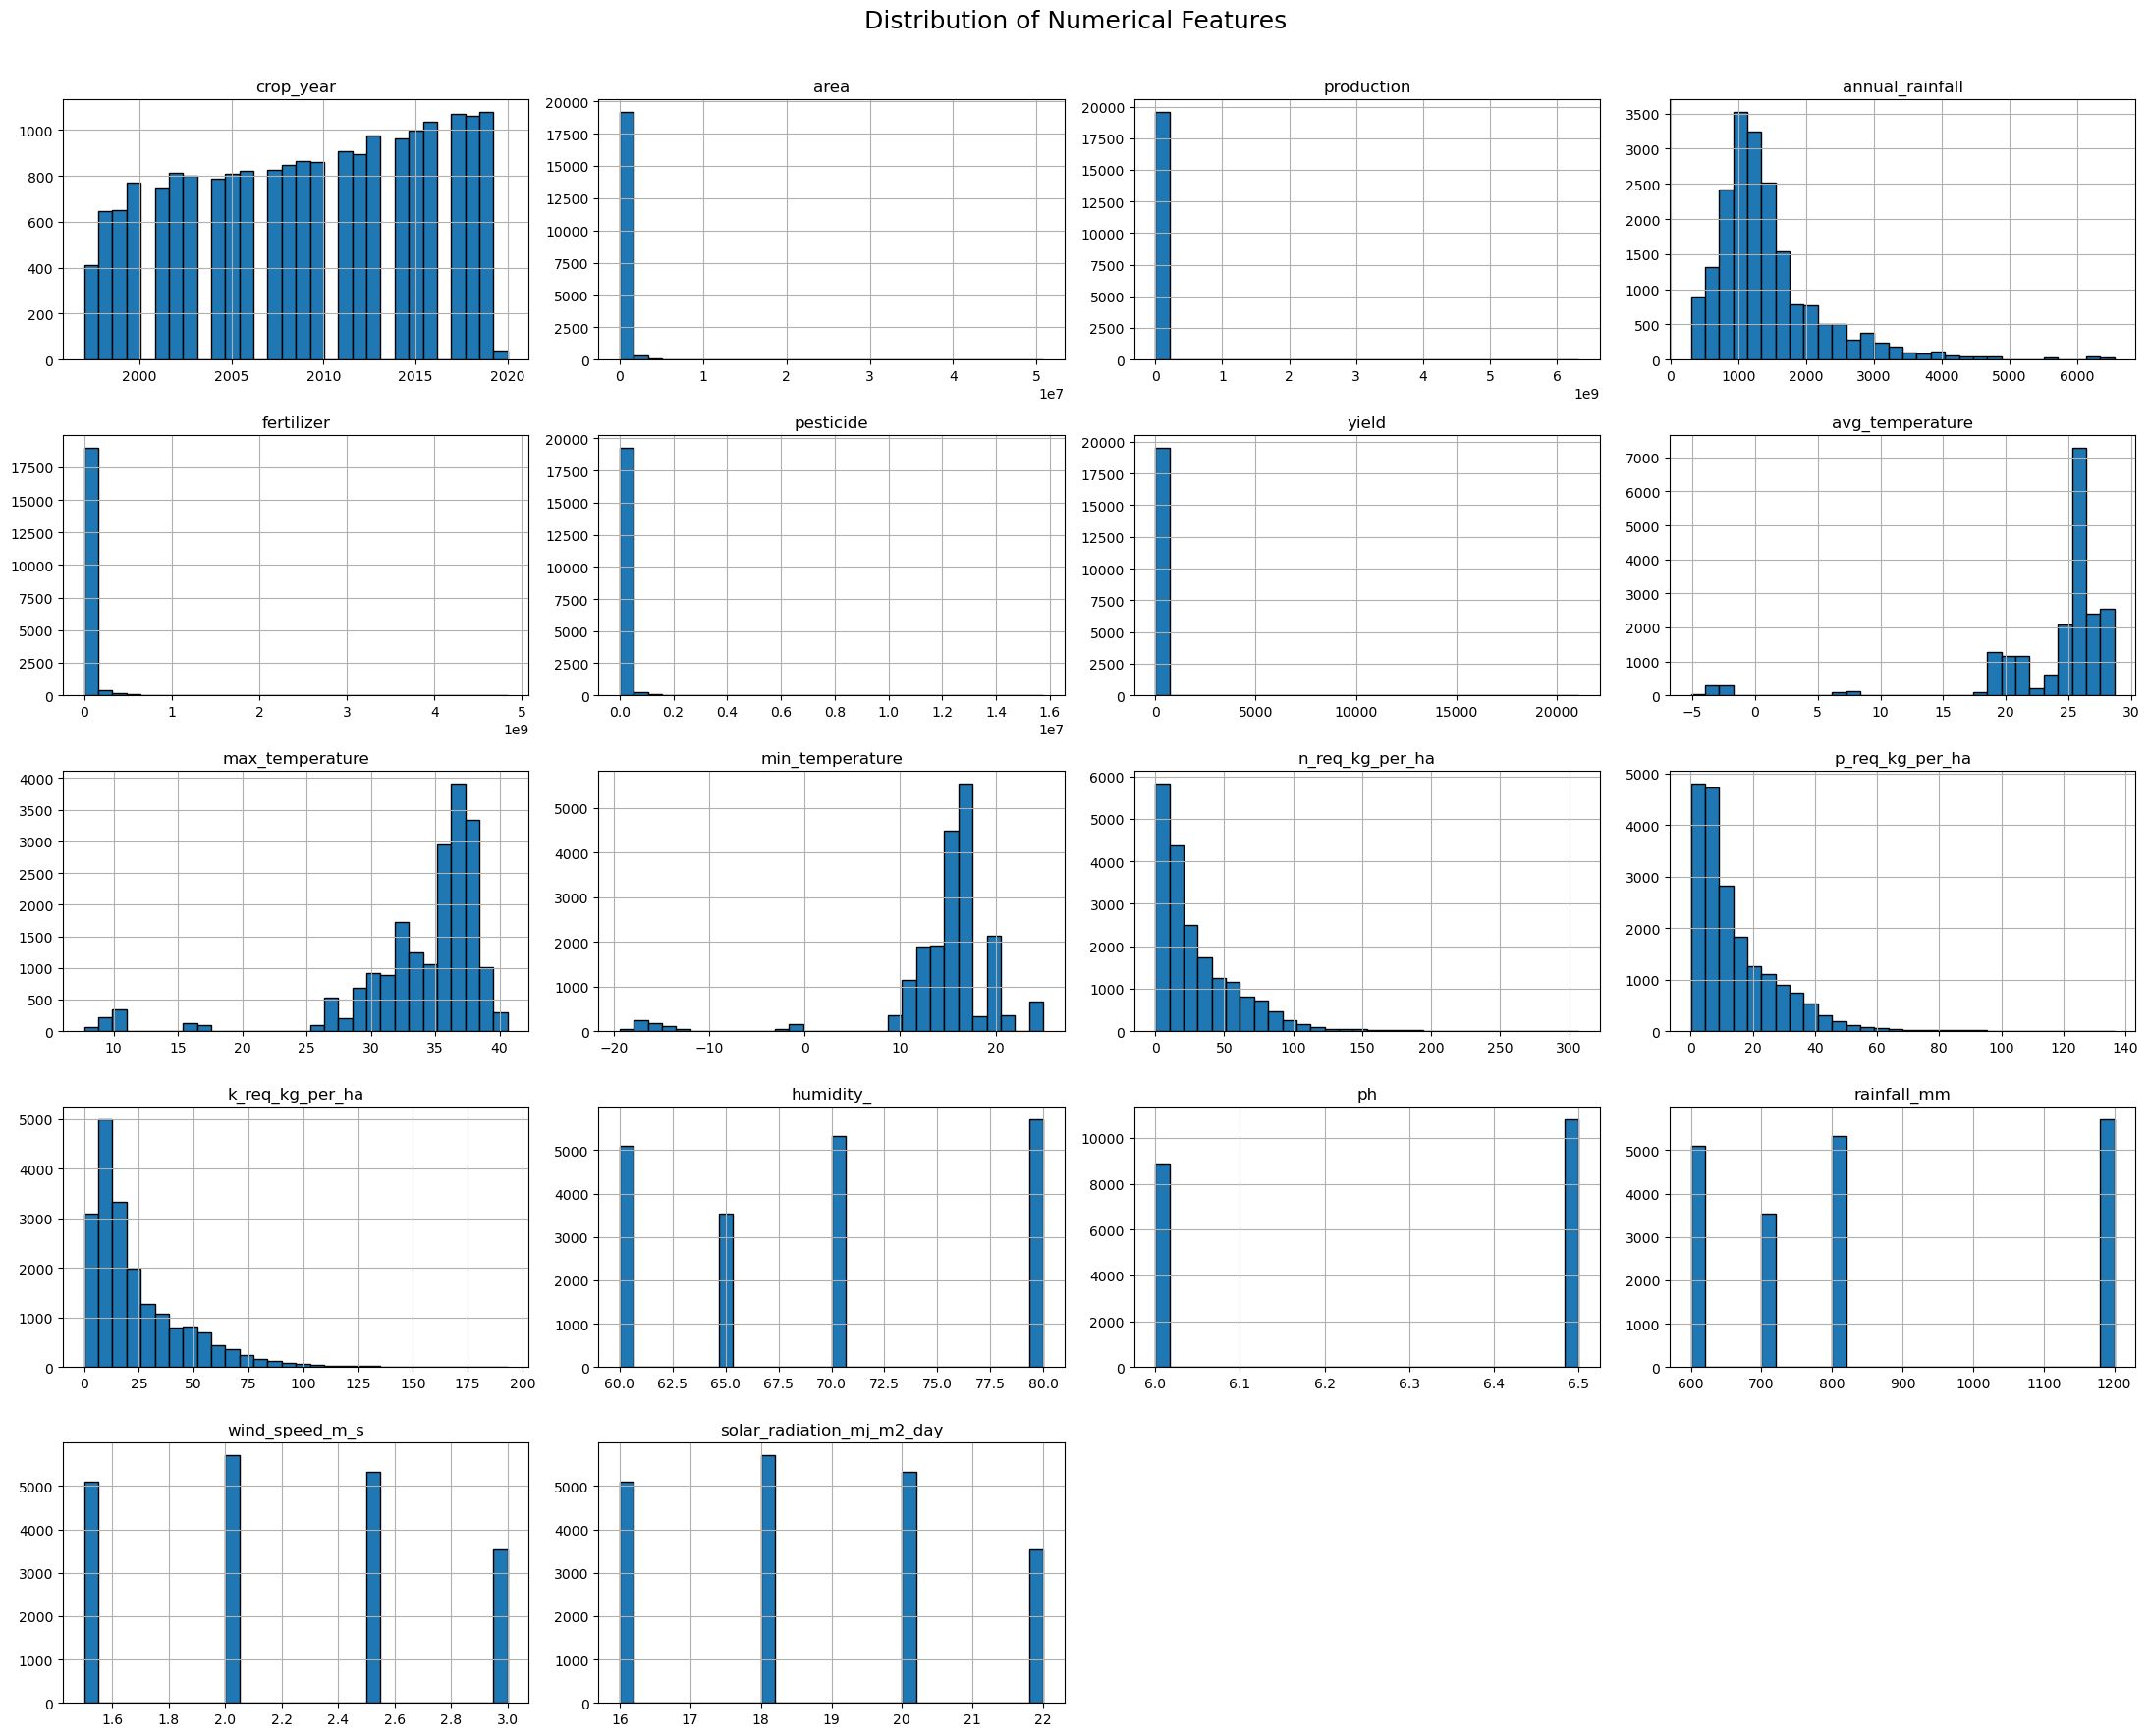

In [51]:
#Histogram plots
final_table[numeric_cols].hist(
    bins=30,
    figsize=(22,18),
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

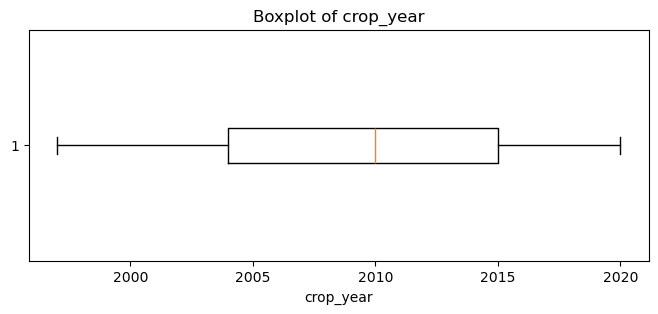

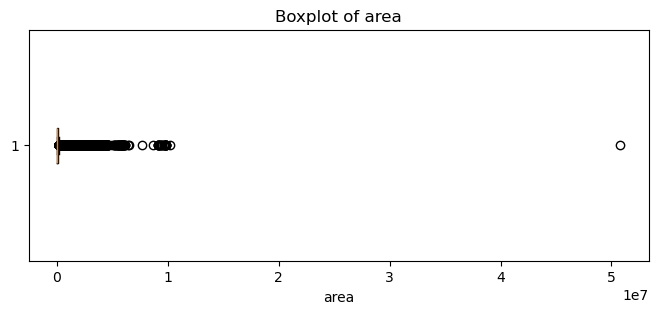

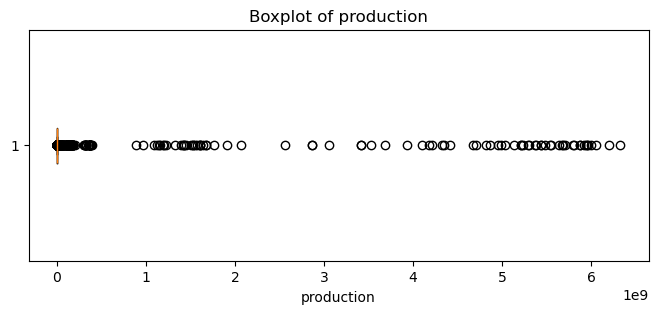

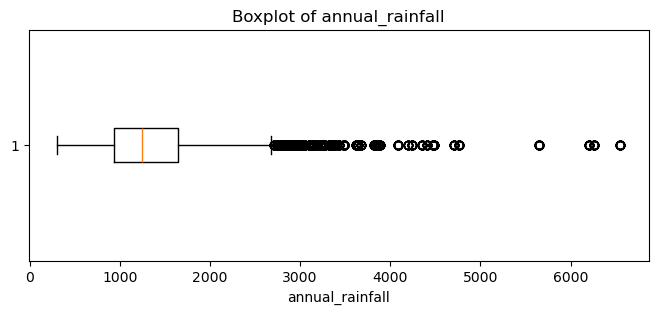

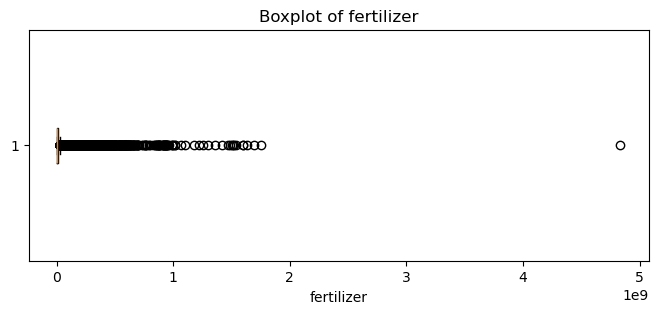

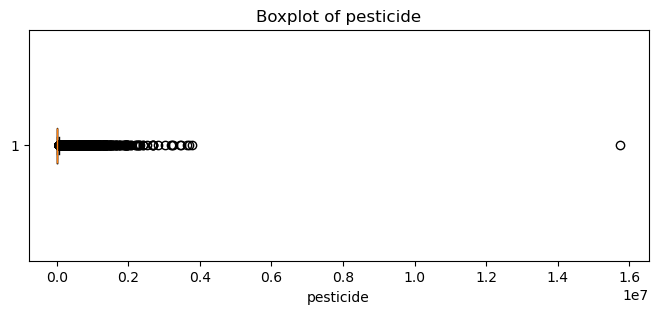

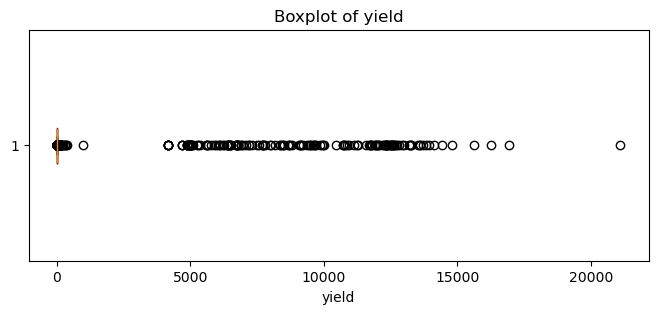

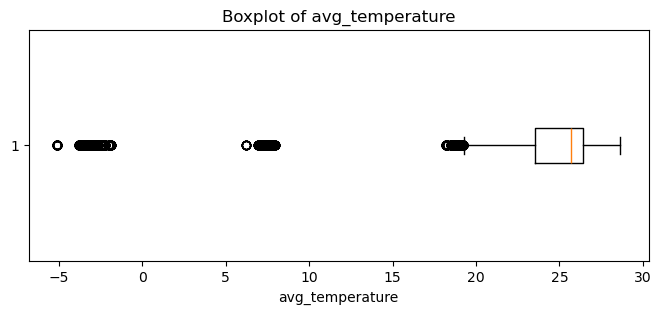

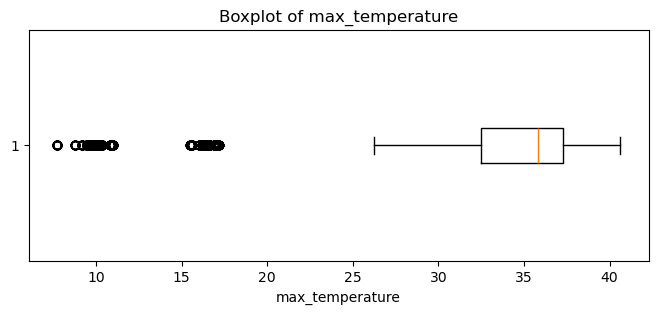

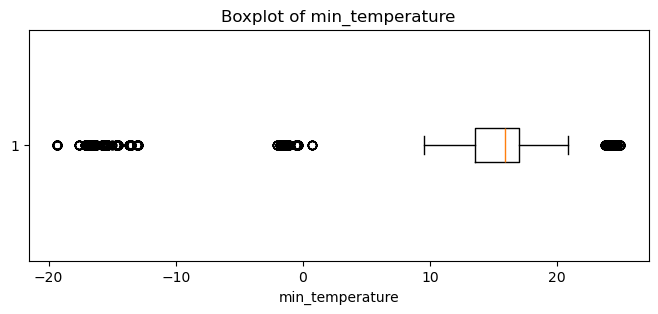

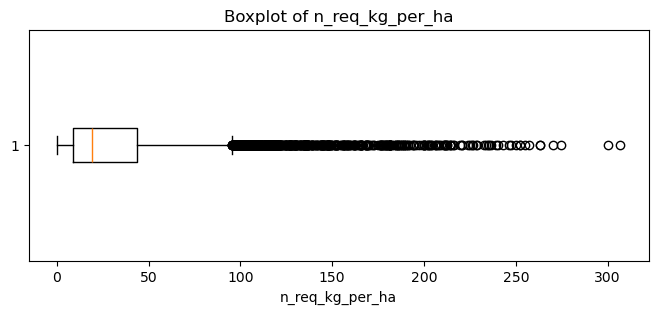

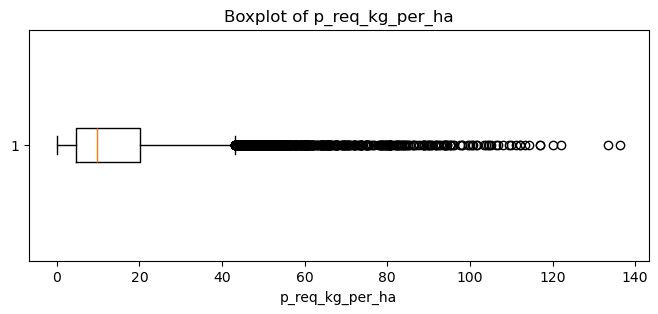

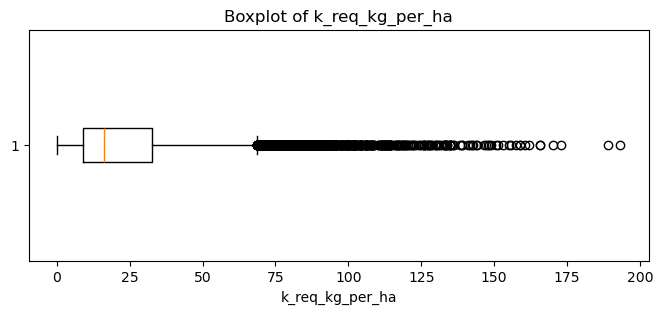

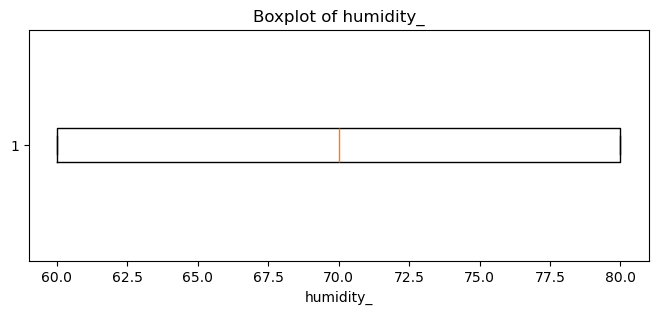

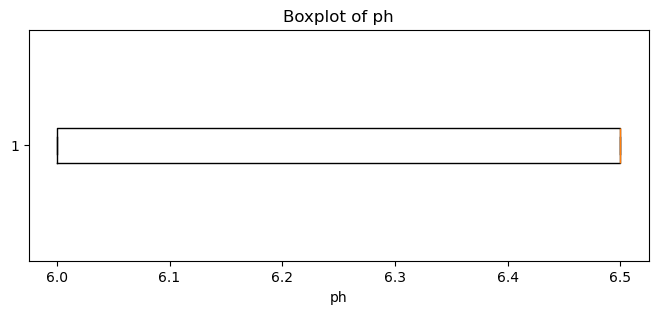

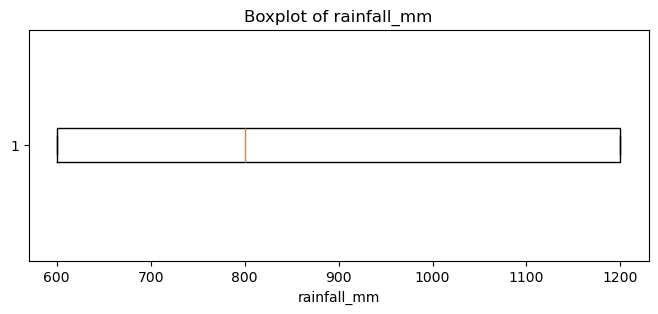

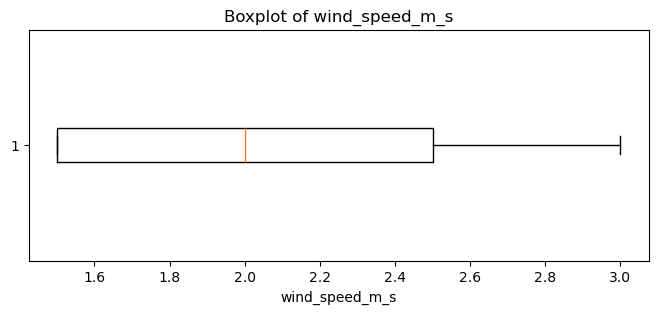

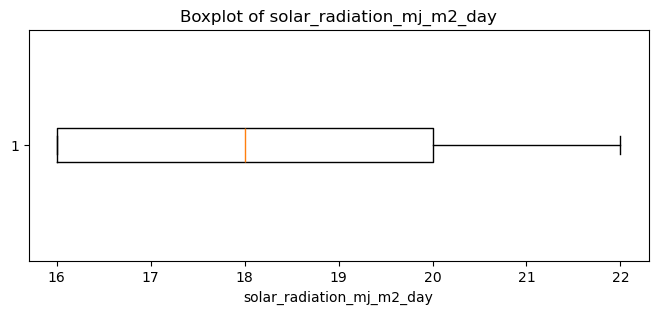

In [52]:
#BOXplots
for col in numeric_cols:

    plt.figure(figsize=(8,3))

    plt.boxplot(
        final_table[col].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

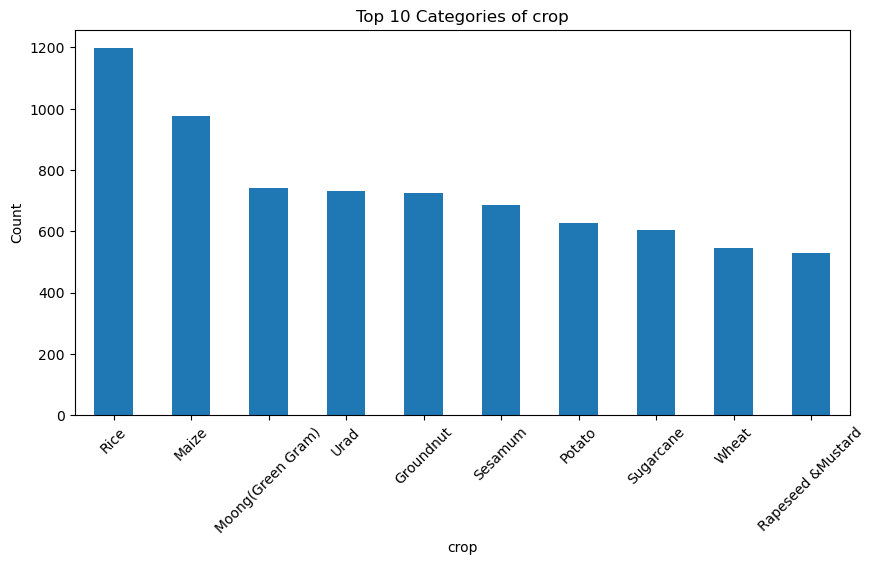

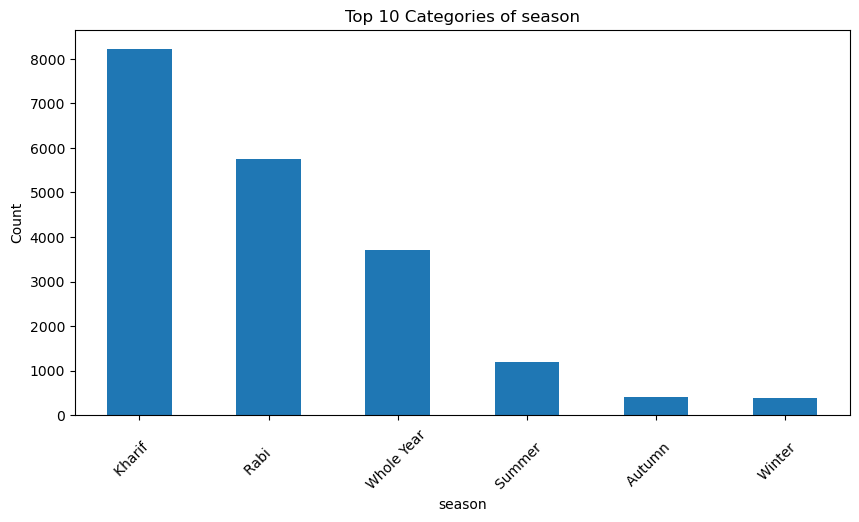

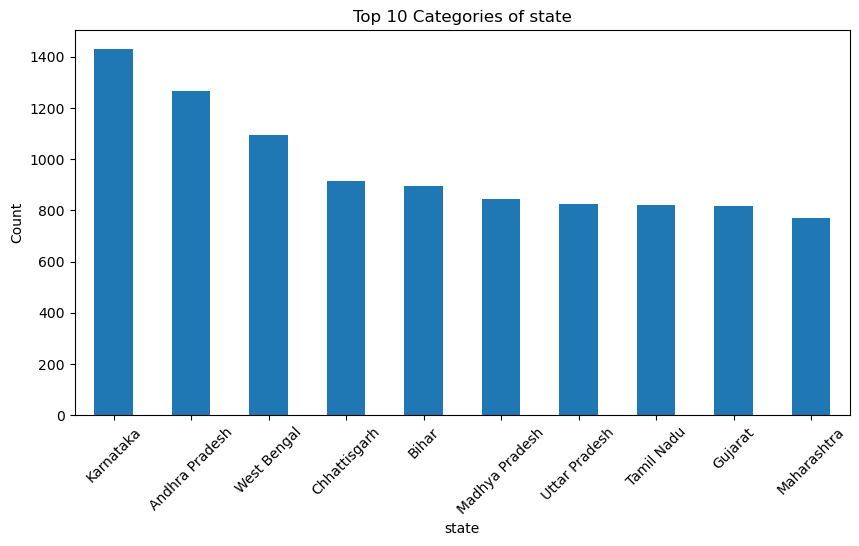

In [53]:
# BAR CHARTS FOR CATEGORICAL FEATURES
for col in categorical_cols:
    if final_table[col].dropna().empty:
        print(f"Skipping '{col}' because it has no data.")
        continue
    plt.figure(figsize=(10,5))
    final_table[col].value_counts().head(10).plot(
        kind="bar"
    )
    plt.title(f"Top 10 Categories of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [47]:
#Value counts
for col in categorical_cols:

    print("\n"+"="*70)
    print(f"VALUE COUNTS : {col.upper()}")
    print("="*70)

    print(final_table[col].value_counts())


VALUE COUNTS : CROP
crop
rice                     1197
maize                     975
moong(green gram)         740
urad                      733
groundnut                 725
sesamum                   685
potato                    628
sugarcane                 605
wheat                     545
rapeseed &mustard         528
bajra                     524
jowar                     513
arhar/tur                 508
ragi                      498
gram                      490
small millets             485
cotton(lint)              476
onion                     454
sunflower                 441
dry chillies              419
other kharif pulses       382
horse-gram                371
peas & beans (pulses)     369
tobacco                   364
other  rabi pulses        355
soyabean                  349
turmeric                  337
masoor                    324
ginger                    323
linseed                   308
castor seed               300
barley                    297
sweet potato  

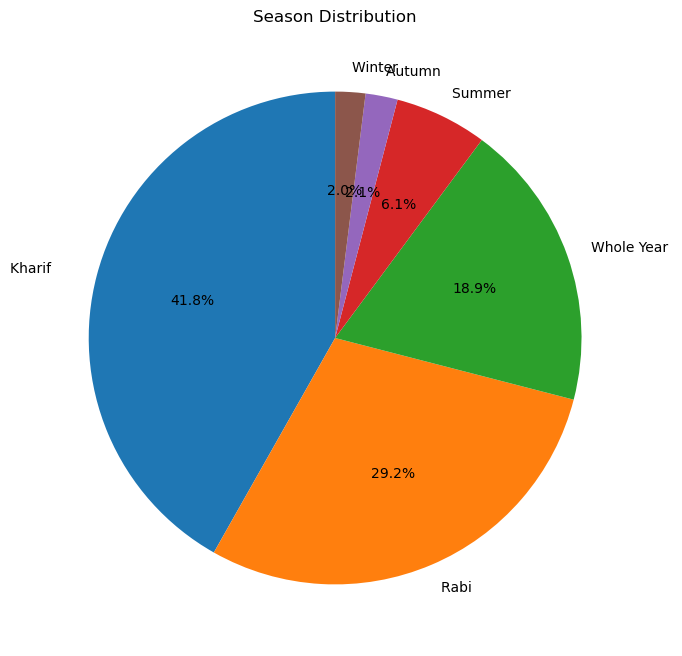

In [24]:
#pie chart
crop_counts = final_table["season"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    crop_counts,
    labels=crop_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Season Distribution")

plt.show()

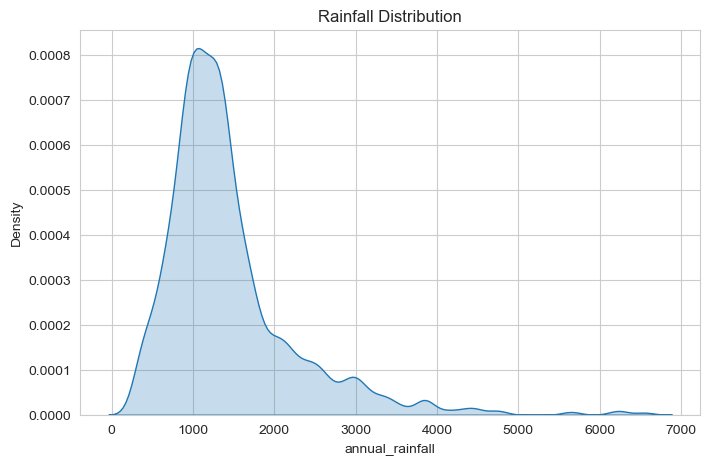

In [53]:
#KDE plot
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=final_table,
    x="annual_rainfall",
    fill=True
)

plt.title("Rainfall Distribution")

plt.show()

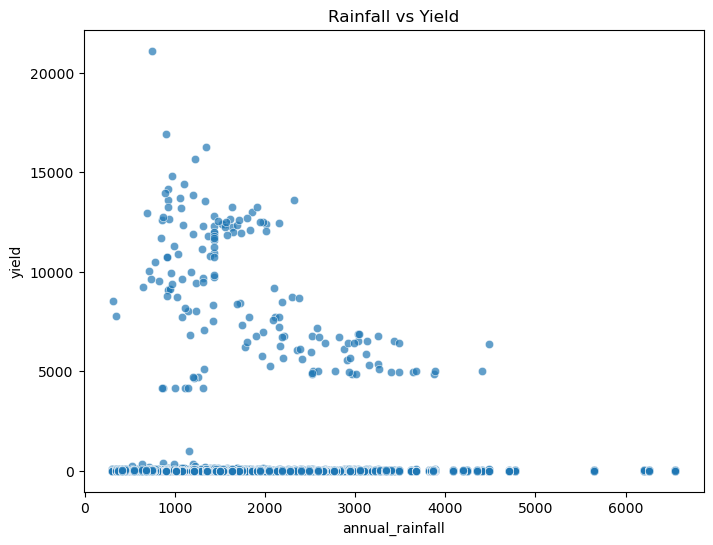

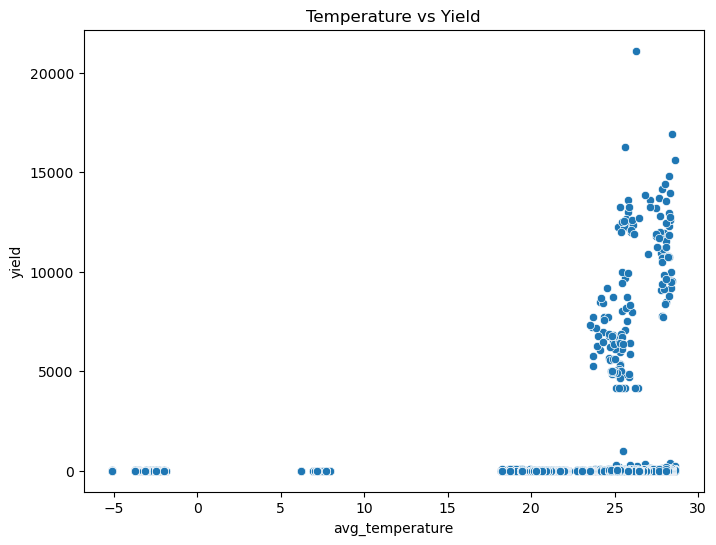

In [25]:
#scatter plot 
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=final_table,
    x="annual_rainfall",
    y="yield",
    alpha=0.7
)
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=final_table,
    x="avg_temperature",
    y="yield"
)
plt.title("Temperature vs Yield")
plt.show()

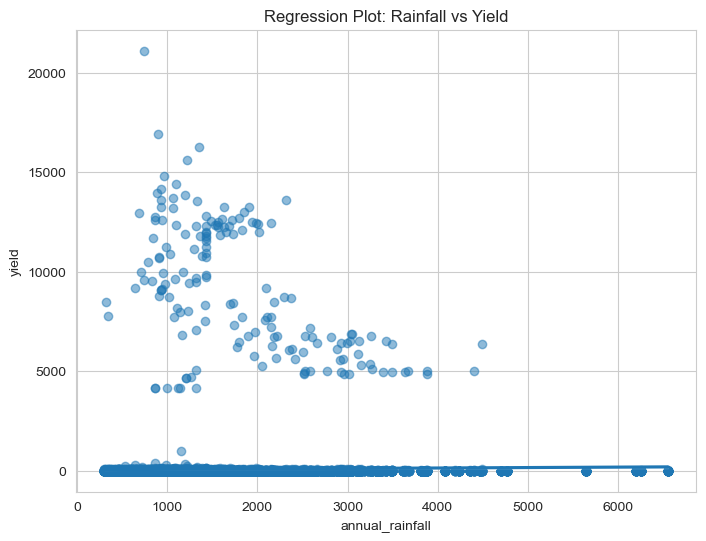

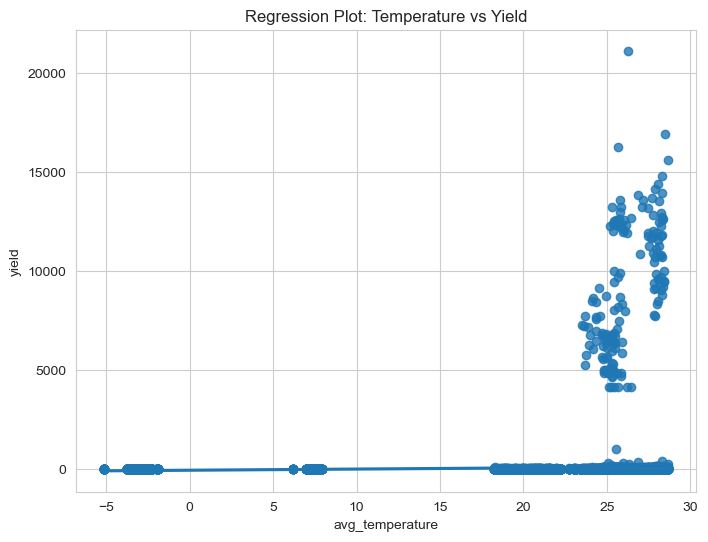

In [59]:
#Regression plot
plt.figure(figsize=(8,6))
sns.regplot(
    data=final_table,
    x="annual_rainfall",
    y="yield",
    scatter_kws={"alpha":0.5}
)
plt.title("Regression Plot: Rainfall vs Yield")
plt.show()

plt.figure(figsize=(8,6))
sns.regplot(
    data=final_table,
    x="avg_temperature",
    y="yield"
)
plt.title("Regression Plot: Temperature vs Yield")
plt.show()

In [62]:
#Regression(Annual rainfall vs yeild)
regression_drop = [
    "annual_rainfall",
    "yield"
]

# Only drop columns that actually exist
regression_drop = [
    col for col in regression_drop
    if col in final_table.columns
]

X_reg = final_table.drop(
    columns=regression_drop
)

y_reg = final_table["annual_rainfall"]

print("Regression X shape:", X_reg.shape)
print("Regression y shape:", y_reg.shape)

Regression X shape: (19689, 19)
Regression y shape: (19689,)


In [64]:
#Removing high-cardinality identifier columns
id_columns = [
    "dist_code",
    "state_code"
]

id_columns = [
    col for col in id_columns
    if col in X_reg.columns
]

X_reg = X_reg.drop(
    columns=id_columns
)

print(X_reg.columns.tolist())

['crop', 'crop_year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'avg_temperature', 'max_temperature', 'min_temperature', 'n_req_kg_per_ha', 'p_req_kg_per_ha', 'k_req_kg_per_ha', 'humidity_', 'ph', 'rainfall_mm', 'wind_speed_m_s', 'solar_radiation_mj_m2_day']


In [65]:
#Identifiy numerical and categorial columns
numeric_features_reg = X_reg.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_reg = X_reg.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features_reg)

print("\nCategorical features:")
print(categorical_features_reg)

Numerical features:
['crop_year', 'area', 'production', 'fertilizer', 'pesticide', 'avg_temperature', 'max_temperature', 'min_temperature', 'n_req_kg_per_ha', 'p_req_kg_per_ha', 'k_req_kg_per_ha', 'humidity_', 'ph', 'rainfall_mm', 'wind_speed_m_s', 'solar_radiation_mj_m2_day']

Categorical features:
['crop', 'season', 'state']


In [69]:

#Regression preprocessing
numeric_transformer_reg = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer_reg = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_reg,
            numeric_features_reg
        ),
        (
            "cat",
            categorical_transformer_reg,
            categorical_features_reg
        )
    ]
)

In [70]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train_reg.shape)
print("Testing :", X_test_reg.shape)

Training: (15751, 19)
Testing : (3938, 19)


In [71]:
regression_models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge Regression":
        Ridge(alpha=1.0),

    "Lasso Regression":
        Lasso(alpha=0.01),

    "ElasticNet Regression":
        ElasticNet(
            alpha=0.01,
            l1_ratio=0.5
        ),

    "Decision Tree Regressor":
        DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        ),

    "Random Forest Regressor":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting Regressor":
        GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

    "SVR":
        SVR(
            C=1.0,
            kernel="rbf"
        ),

    "KNN Regressor":
        KNeighborsRegressor(
            n_neighbors=5
        )
}

In [72]:
regression_results = []

regression_predictions = {}

regression_pipelines = {}

for name, model in regression_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor_reg
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train_reg,
        y_train_reg
    )

    predictions = pipeline.predict(
        X_test_reg
    )

    r2 = r2_score(
        y_test_reg,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test_reg,
        predictions
    )

    regression_results.append([
        name,
        r2,
        rmse,
        mae
    ])

    regression_predictions[name] = predictions
    regression_pipelines[name] = pipeline

C:\Users\gatta\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.013e+08, tolerance: 1.046e+06
  model = cd_fast.sparse_enet_coordinate_descent(


In [76]:
#polynomial regression
polynomial_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_reg
        ),
        (
            "polynomial",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

polynomial_pipeline.fit(
    X_train_reg,
    y_train_reg
)

y_pred_poly = polynomial_pipeline.predict(
    X_test_reg
)

poly_r2 = r2_score(
    y_test_reg,
    y_pred_poly
)

poly_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_poly
    )
)

poly_mae = mean_absolute_error(
    y_test_reg,
    y_pred_poly
)

regression_results.append([
    "Polynomial Regression",
    poly_r2,
    poly_rmse,
    poly_mae
])

regression_predictions[
    "Polynomial Regression"
] = y_pred_poly

regression_pipelines[
    "Polynomial Regression"
] = polynomial_pipeline

In [77]:
regression_results_df = pd.DataFrame(
    regression_results,
    columns=[
        "Model",
        "R2",
        "RMSE",
        "MAE"
    ]
)

regression_results_df = regression_results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

display(regression_results_df)

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.999969,4.583916,0.630021
1,Gradient Boosting Regressor,0.934789,210.445781,156.325886
2,Polynomial Regression,0.883168,281.683208,182.448096
3,Ridge Regression,0.864635,303.203696,189.640133
4,Linear Regression,0.864581,303.263509,189.876935
5,Lasso Regression,0.864306,303.571150,190.110355
6,ElasticNet Regression,0.848702,320.551676,202.401604
7,KNN Regressor,0.841967,327.608360,203.838406
8,Decision Tree Regressor,0.800592,368.003640,263.943958
9,SVR,0.118785,773.609354,480.490263


In [78]:
best_regression_name = (
    regression_results_df.iloc[0]["Model"]
)

print(
    "Best Regression Model:",
    best_regression_name
)

print(
    "R²:",
    regression_results_df.iloc[0]["R2"]
)

print(
    "RMSE:",
    regression_results_df.iloc[0]["RMSE"]
)

print(
    "MAE:",
    regression_results_df.iloc[0]["MAE"]
)

Best Regression Model: Random Forest Regressor
R²: 0.9999690606217899
RMSE: 4.5839155370103235
MAE: 0.6300206221447007


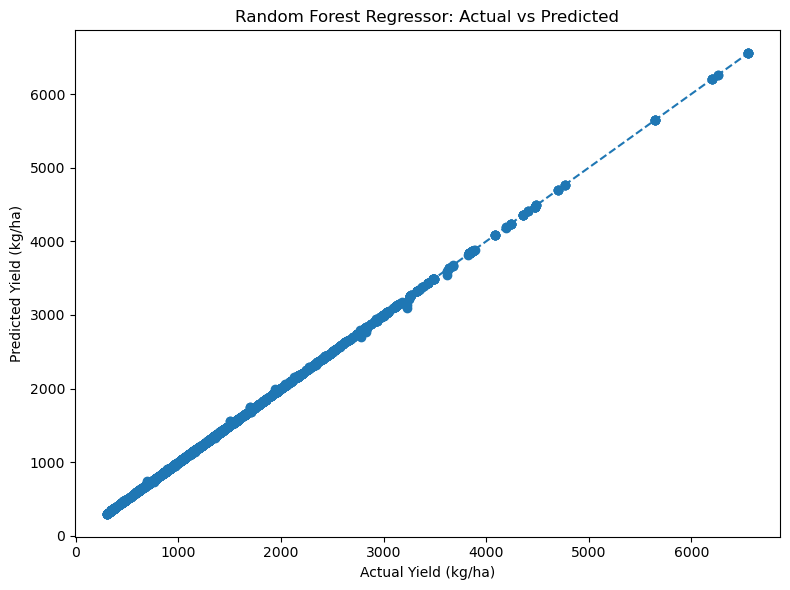

In [80]:
best_reg_predictions = regression_predictions[
    best_regression_name
]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    best_reg_predictions
)

plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")

plt.title(
    f"{best_regression_name}: Actual vs Predicted"
)

plt.plot(
    [
        y_test_reg.min(),
        y_test_reg.max()
    ],
    [
        y_test_reg.min(),
        y_test_reg.max()
    ],
    linestyle="--"
)

plt.tight_layout()
plt.show()

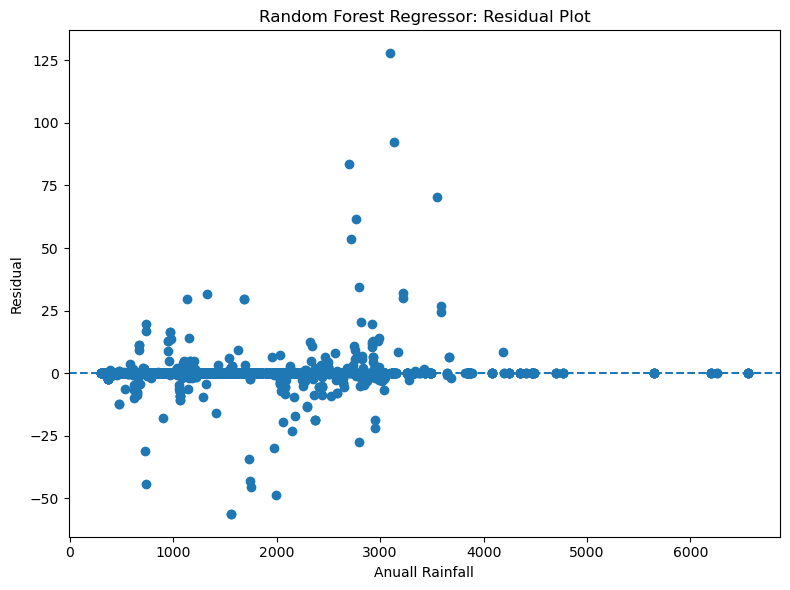

In [83]:
residuals = (
    y_test_reg -
    best_reg_predictions
)

plt.figure(figsize=(8, 6))

plt.scatter(
    best_reg_predictions,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Anuall Rainfall")
plt.ylabel("Residual")
plt.title(
    f"{best_regression_name}: Residual Plot"
)

plt.tight_layout()
plt.show()

In [85]:
#Classification (crop based on agriculture/environmental characterisitics)
classification_drop = [
    "crop",
    "yield_kg_per_ha",
    "yield"
]

classification_drop = [
    col for col in classification_drop
    if col in final_table.columns
]

X_cls = final_table.drop(
    columns=classification_drop
)

y_cls = final_table["crop"]

print("Classification X shape:", X_cls.shape)
print("Classification y shape:", y_cls.shape)

Classification X shape: (19689, 19)
Classification y shape: (19689,)


In [86]:
id_columns_cls = [
    "dist_code",
    "state_code"
]

id_columns_cls = [
    col for col in id_columns_cls
    if col in X_cls.columns
]

X_cls = X_cls.drop(
    columns=id_columns_cls
)

print(X_cls.columns.tolist())

['crop_year', 'season', 'state', 'area', 'production', 'annual_rainfall', 'fertilizer', 'pesticide', 'avg_temperature', 'max_temperature', 'min_temperature', 'n_req_kg_per_ha', 'p_req_kg_per_ha', 'k_req_kg_per_ha', 'humidity_', 'ph', 'rainfall_mm', 'wind_speed_m_s', 'solar_radiation_mj_m2_day']


In [87]:
print(
    "Number of crop classes:",
    y_cls.nunique()
)

print("\nCrop distribution:")

display(
    y_cls.value_counts().head(20)
)

Number of crop classes: 55

Crop distribution:


crop
Rice                 1197
Maize                 975
Moong(Green Gram)     740
Urad                  733
Groundnut             725
Sesamum               685
Potato                628
Sugarcane             605
Wheat                 545
Rapeseed &Mustard     528
Bajra                 524
Jowar                 513
Arhar/Tur             508
Ragi                  498
Gram                  490
Small millets         485
Cotton(lint)          476
Onion                 454
Sunflower             441
Dry chillies          419
Name: count, dtype: int64

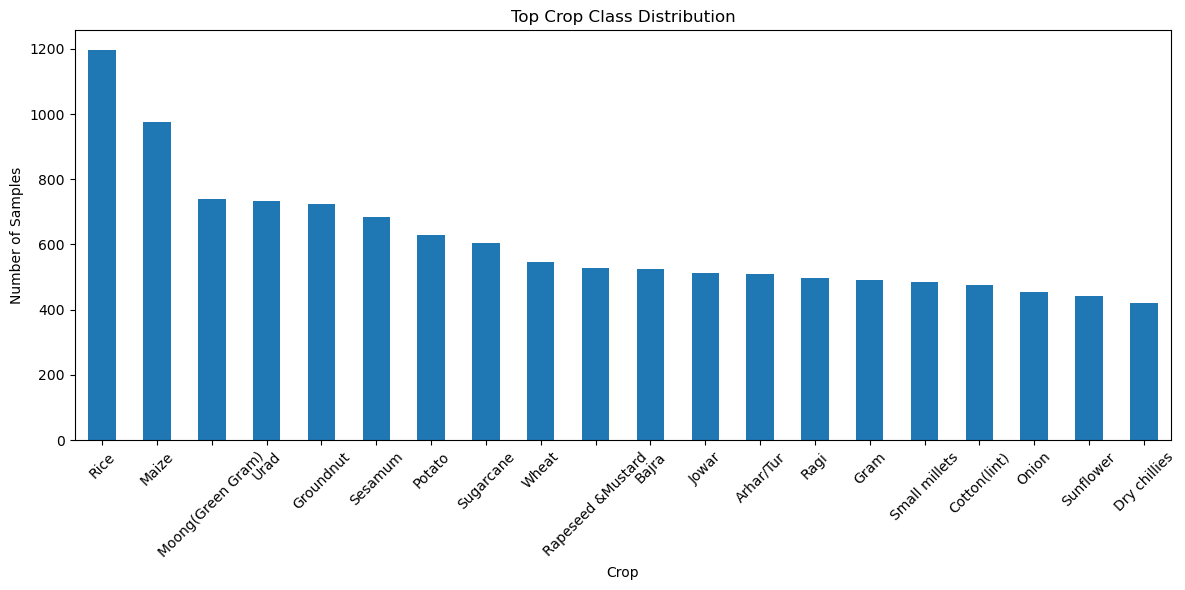

In [88]:
plt.figure(figsize=(12, 6))

y_cls.value_counts().head(20).plot(
    kind="bar"
)

plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.title("Top Crop Class Distribution")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [89]:
numeric_features_cls = X_cls.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_cls = X_cls.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features_cls)

print("\nCategorical features:")
print(categorical_features_cls)

Numerical features:
['crop_year', 'area', 'production', 'annual_rainfall', 'fertilizer', 'pesticide', 'avg_temperature', 'max_temperature', 'min_temperature', 'n_req_kg_per_ha', 'p_req_kg_per_ha', 'k_req_kg_per_ha', 'humidity_', 'ph', 'rainfall_mm', 'wind_speed_m_s', 'solar_radiation_mj_m2_day']

Categorical features:
['season', 'state']


In [90]:
numeric_transformer_cls = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer_cls = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor_cls = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_cls,
            numeric_features_cls
        ),
        (
            "cat",
            categorical_transformer_cls,
            categorical_features_cls
        )
    ]
)

In [92]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print("Training:", X_train_cls.shape)
print("Testing :", X_test_cls.shape)

Training: (15751, 19)
Testing : (3938, 19)


In [93]:
classification_models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "KNN Classification":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Gaussian Naive Bayes":
        GaussianNB(),

    "Decision Tree Classifier":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "SVM":
        SVC(
            C=1.0,
            kernel="rbf",
            random_state=42
        )
}

In [95]:
classification_results = []

classification_predictions = {}

classification_pipelines = {}

for name, model in classification_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor_cls
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train_cls,
        y_train_cls
    )

    predictions = pipeline.predict(
        X_test_cls
    )

    accuracy = accuracy_score(
        y_test_cls,
        predictions
    )

    precision = precision_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    classification_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    classification_predictions[name] = predictions
    classification_pipelines[name] = pipeline

In [98]:
classification_results_df = pd.DataFrame(
    classification_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

classification_results_df = (
    classification_results_df
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(classification_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree Classifier,0.168360,0.135849,0.168360,0.121187
1,Logistic Regression,0.141696,0.117256,0.141696,0.120707
2,KNN Classification,0.109954,0.131050,0.109954,0.110361
3,SVM,0.140427,0.111343,0.140427,0.100932
4,Gaussian Naive Bayes,0.044693,0.082567,0.044693,0.025419


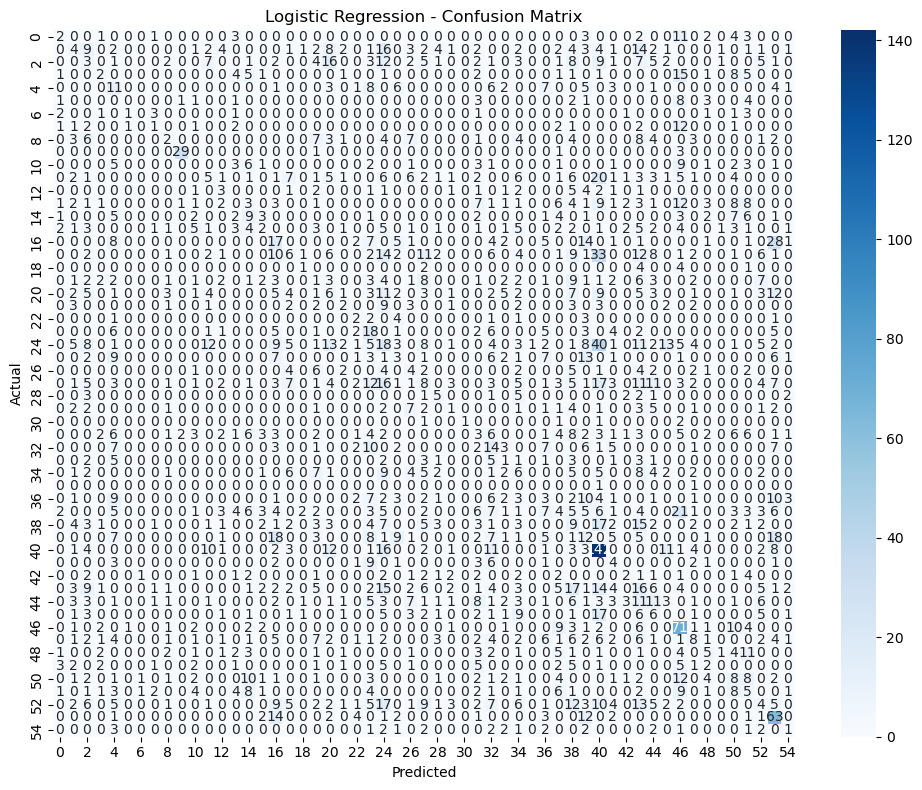

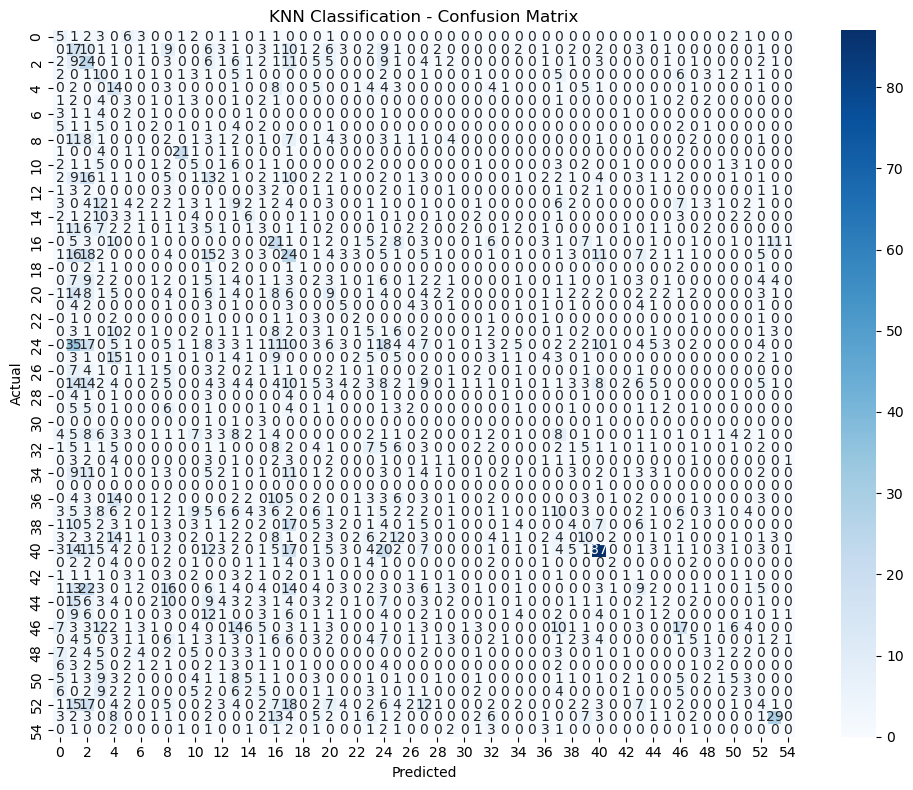

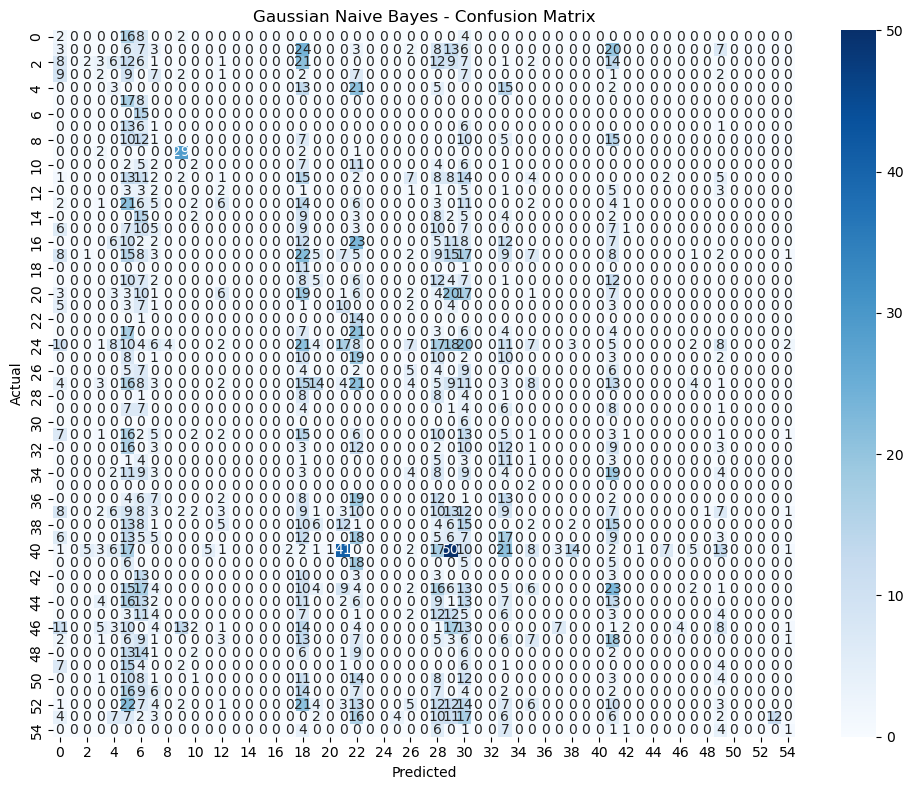

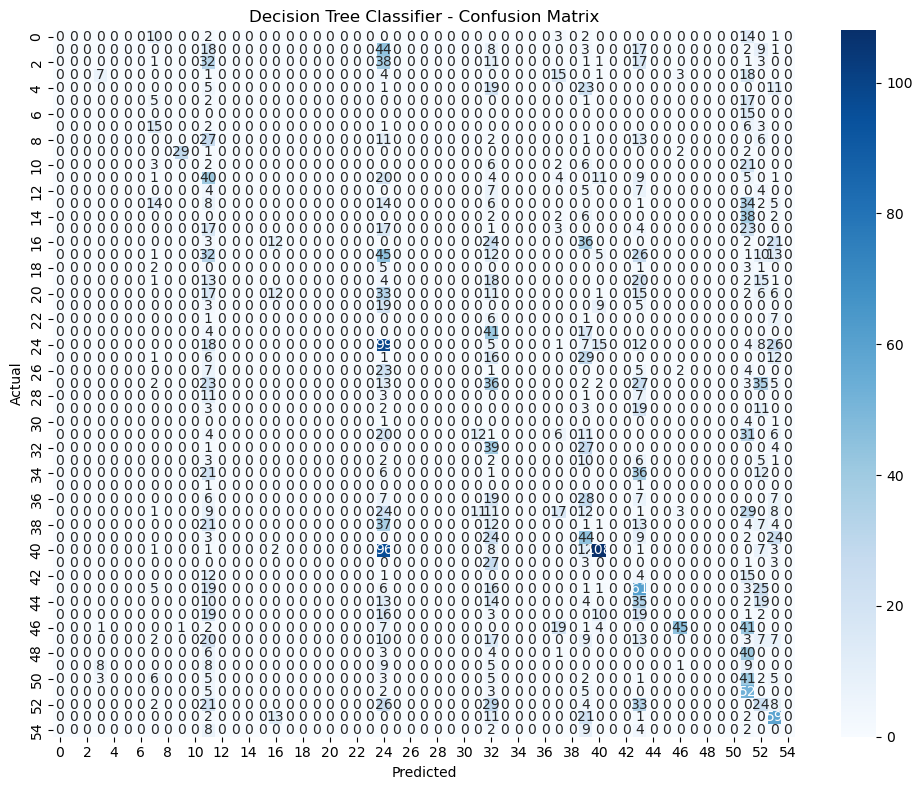

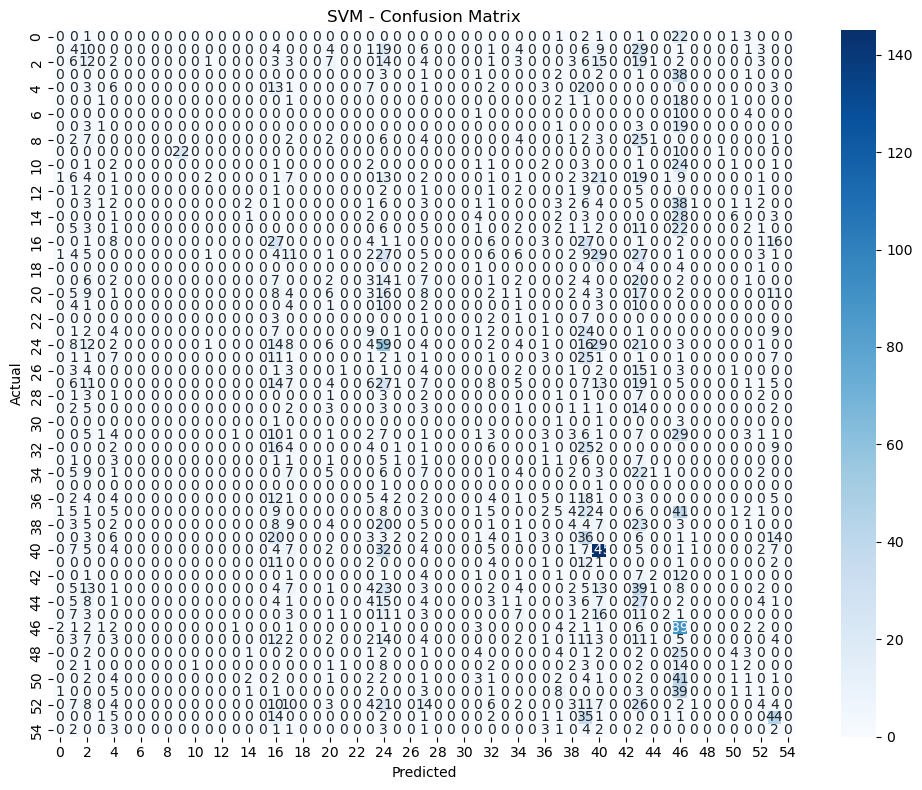

In [99]:
for name, predictions in classification_predictions.items():

    cm = confusion_matrix(
        y_test_cls,
        predictions
    )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(
        f"{name} - Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

In [102]:
best_classification_name = (
    classification_results_df.iloc[0]["Model"]
)

best_cls_predictions = (
    classification_predictions[
        best_classification_name
    ]
)

print(
    "Best Classification Model:",
    best_classification_name
)

print(
    classification_report(
        y_test_cls,
        best_cls_predictions,
        zero_division=0
    )
)

Best Classification Model: Decision Tree Classifier
                       precision    recall  f1-score   support

             Arecanut       0.00      0.00      0.00        32
            Arhar/Tur       0.00      0.00      0.00       102
                Bajra       0.00      0.00      0.00       105
               Banana       0.37      0.14      0.21        49
               Barley       0.00      0.00      0.00        59
         Black pepper       0.00      0.00      0.00        25
             Cardamom       0.00      0.00      0.00        15
            Cashewnut       0.21      0.56      0.30        27
          Castor seed       0.00      0.00      0.00        60
             Coconut        0.97      0.85      0.91        34
            Coriander       0.00      0.00      0.00        40
         Cotton(lint)       0.08      0.42      0.13        95
        Cowpea(Lobia)       0.00      0.00      0.00        27
         Dry chillies       0.00      0.00      0.00        84
  